# Analytical mechanics → fiber rays
### SymPy derivation + torch ray tracing in a graded-index fiber

Fermat's principle ($\delta\int n\,ds=0$) is Hamilton's principle ($\delta\int L\,dt=0$)
wearing an optics costume. So a light ray is a *particle trajectory*, and we can
trace it with **Hamilton's equations** — here, with PyTorch autograd supplying
the canonical derivatives (differentiable physics).

Medium: a parabolic graded-index (GRIN) fiber, $n(x)=n_0\sqrt{1-(x/a)^2}$. The
payoff: rays oscillate sinusoidally and **refocus** — exactly how a GRIN lens / a
graded-index multimode fiber images light.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, sympy as sp, torch
import matplotlib.pyplot as plt
sp.init_printing()
print("torch", torch.__version__)

torch 2.11.0+cu128


## 1. SymPy: from Fermat to the ray Hamiltonian

With $z$ as the evolution parameter and $x'=dx/dz$, the optical path is
$\int n(x)\sqrt{1+x'^2}\,dz$, so $L=n\sqrt{1+x'^2}$. The canonical momentum
$p=\partial L/\partial x'$ and a Legendre transform give the clean Hamiltonian
$H=-\sqrt{n^2-p^2}$.

In [2]:
xs, xp, psym, n0, a = sp.symbols("x x' p n_0 a", positive=True)
n = n0 * sp.sqrt(1 - (xs / a)**2)          # parabolic GRIN index
L = n * sp.sqrt(1 + xp**2)                  # optical Lagrangian
p_of_xp = sp.simplify(sp.diff(L, xp))       # canonical momentum p = dL/dx'
H = -sp.sqrt(n**2 - psym**2)                # ray Hamiltonian
print("L  ="); sp.pprint(L)
print("p  ="); sp.pprint(p_of_xp)
print("H  ="); sp.pprint(H)

L  =
         ________             
        ╱      2     _________
       ╱      x     ╱   2     
n₀⋅   ╱   1 - ── ⋅╲╱  x'  + 1 
     ╱         2              
   ╲╱         a               
p  =
         _________
        ╱  2    2 
n₀⋅x'⋅╲╱  a  - x  
──────────────────
       _________  
      ╱   2       
  a⋅╲╱  x'  + 1   
H  =
       ___________________
      ╱     ⎛     2⎞      
     ╱    2 ⎜    x ⎟    2 
-   ╱   n₀ ⋅⎜1 - ──⎟ - p  
   ╱        ⎜     2⎟      
 ╲╱         ⎝    a ⎠      


### Hamilton's equations (exact), then the paraxial limit

$\dot x=\partial H/\partial p,\ \dot p=-\partial H/\partial x$. In the paraxial
limit $|p|\ll n$, $\sqrt{n^2-p^2}\approx n_0$, and the parabolic index gives
$\dfrac{d^2x}{dz^2}=-\dfrac{x}{a^2}$ — **simple harmonic motion**. Rays are sine
waves with pitch $2\pi a$.

In [3]:
dxdz = sp.simplify(sp.diff(H, psym))         # exact dx/dz
dpdz = sp.simplify(-sp.diff(H, xs))          # exact dp/dz
print("dx/dz ="); sp.pprint(dxdz)
print("dp/dz ="); sp.pprint(dpdz)

# paraxial ray equation and its solution
z = sp.symbols("z", real=True)
X = sp.Function("X")
ray_ode = sp.Eq(X(z).diff(z, 2), -X(z) / a**2)
sol = sp.dsolve(ray_ode, X(z))
print("paraxial ray equation:"); sp.pprint(ray_ode)
print("solution:"); sp.pprint(sol)
print("=> rays oscillate; pitch (full period) = 2*pi*a, refocus at z = pi*a")

dx/dz =


            a⋅p             
────────────────────────────
   _________________________
  ╱    2  2     2 ⎛ 2    2⎞ 
╲╱  - a ⋅p  + n₀ ⋅⎝a  - x ⎠ 
dp/dz =
              2               
           -n₀ ⋅x             
──────────────────────────────
     _________________________
    ╱    2  2     2 ⎛ 2    2⎞ 
a⋅╲╱  - a ⋅p  + n₀ ⋅⎝a  - x ⎠ 
paraxial ray equation:
 2                
d           -X(z) 
───(X(z)) = ──────
  2            2  
dz            a   
solution:
             ⎛z⎞         ⎛z⎞
X(z) = C₁⋅sin⎜─⎟ + C₂⋅cos⎜─⎟
             ⎝a⎠         ⎝a⎠
=> rays oscillate; pitch (full period) = 2*pi*a, refocus at z = pi*a


## 2. torch: trace the rays with autograd

We integrate the **exact** (non-paraxial) Hamilton's equations. The trick: define
$H(x,p)$ as a torch tensor and let `autograd` produce $\partial H/\partial p$ and
$\partial H/\partial x$ — no hand-differentiation, and the whole tracer stays
differentiable. RK4 in $z$, a fan of rays launched from a point.

In [4]:
n0v, av = 1.5, 1.0

def deriv(x, p):
    x = x.detach().requires_grad_(True)
    p = p.detach().requires_grad_(True)
    H = (-torch.sqrt(n0v**2 * (1 - (x / av)**2) - p**2)).sum()
    gx, gp = torch.autograd.grad(H, [x, p])
    return gp, -gx                            # dx/dz, dp/dz  (Hamilton)

def rk4_step(x, p, dz):
    kx1, kp1 = deriv(x, p)
    kx2, kp2 = deriv(x + 0.5*dz*kx1, p + 0.5*dz*kp1)
    kx3, kp3 = deriv(x + 0.5*dz*kx2, p + 0.5*dz*kp2)
    kx4, kp4 = deriv(x + dz*kx3,     p + dz*kp3)
    return (x + dz/6*(kx1 + 2*kx2 + 2*kx3 + kx4),
            p + dz/6*(kp1 + 2*kp2 + 2*kp3 + kp4))

# fan of rays from x=0 with a spread of launch angles theta (p = n0 sin theta)
theta = torch.linspace(-0.3, 0.3, 11)
x = torch.zeros(11)
p = n0v * torch.sin(theta)
dz, Z = 0.01, 4 * np.pi * av
zs = [0.0]; hist = [x.clone()]
for i in range(int(Z / dz)):
    x, p = rk4_step(x, p, dz)
    hist.append(x.clone()); zs.append((i + 1) * dz)
X = torch.stack(hist).numpy(); zs = np.array(zs)
print("traced", X.shape[1], "rays over z in [0,", round(Z, 2), "]")

traced 11 rays over z in [0, 12.57 ]


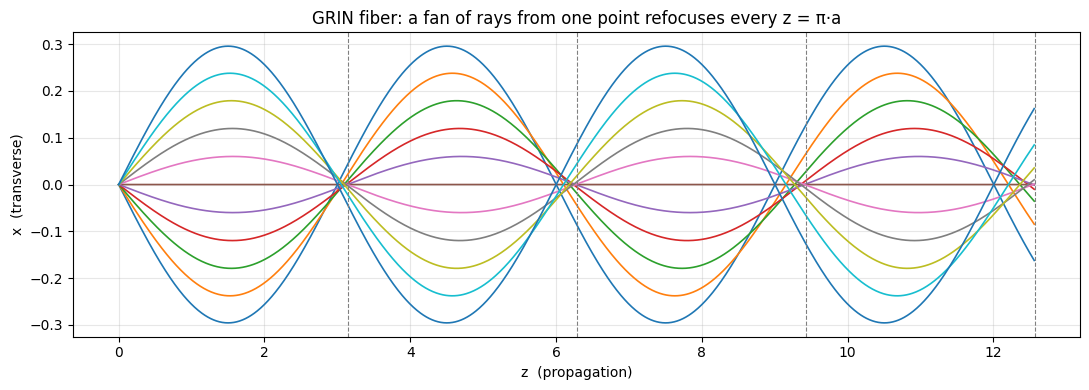

numeric pitch ~ 6.160,  analytic 2*pi*a = 6.283


In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
for k in range(X.shape[1]):
    ax.plot(zs, X[:, k], lw=1.2)
for m in range(1, 5):                          # refocus planes at z = m*pi*a
    ax.axvline(m * np.pi * av, color="grey", ls="--", lw=0.8)
ax.set_xlabel("z  (propagation)"); ax.set_ylabel("x  (transverse)")
ax.set_title("GRIN fiber: a fan of rays from one point refocuses every z = π·a")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

# numeric vs analytic period for a single off-axis ray (x0=0.2, p0=0 -> 0.2 cos(z/a))
x1 = torch.tensor([0.2]); p1 = torch.zeros(1); xs1 = [0.2]
for i in range(int(Z / dz)):
    x1, p1 = rk4_step(x1, p1, dz); xs1.append(float(x1))
xs1 = np.array(xs1)
# the ray starts at a crest; the first *interior* local maximum is one full pitch
dxs = np.diff(xs1)
local_max = np.where((dxs[:-1] > 0) & (dxs[1:] <= 0))[0] + 1
first_peak = local_max[local_max > 5][0]
print(f"numeric pitch ~ {zs[first_peak]:.3f},  analytic 2*pi*a = {2*np.pi*av:.3f}")

## Takeaway

| analytical mechanics | this fiber |
|---|---|
| Hamilton's principle $\delta\int L\,dt$ | Fermat's principle $\delta\int n\,ds$ |
| potential $V(x)$ | index profile $n(x)$ (well = high index) |
| Hamilton's equations | the ray-tracing ODEs |
| SHM in a quadratic well | rays in a **parabolic GRIN** fiber |
| period $2\pi\sqrt{m/k}$ | ray pitch $2\pi a$ |

A fan of rays from a point **refocuses** at every $z=\pi a$ — point-to-point
imaging — which is *why* a GRIN rod is a lens and why graded-index multimode
fiber keeps modes together. And torch's autograd gave us Hamilton's equations
for free: the same differentiable-physics machinery the rest of the repo uses
for phase retrieval. Civilian optical metrology / education.